In [1]:
# Enables autoreload for your modules
%load_ext autoreload
%autoreload 2

# Standard library
import sys
from pathlib import Path

# Locate and set repo root (assuming you have "src" and "notebooks" there)
def find_repo_root_by_subfolders(start_path: Path, required_subfolders=("src", "notebooks"), max_up=5) -> Path:
    current = start_path.resolve()
    for _ in range(max_up):
        if all((current / subfolder).exists() for subfolder in required_subfolders):
            return current
        current = current.parent
    raise FileNotFoundError(f"Could not find repo root with {required_subfolders} within {max_up} levels from {start_path}")

# Find the repo root
repo_root = find_repo_root_by_subfolders(Path())
src_path = repo_root / "src"

# Add src folder to sys.path if not already present
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

# Load .env if needed
from dotenv import load_dotenv
load_dotenv(dotenv_path=repo_root / ".env")

True

In [2]:
import api_handler
import metrics
import setup_env
import sync
import cs_analysis

In [3]:
# === Notebook setup ===

env = setup_env.initialize_environment()

# Access paths or values
repo_root = env["repo_root"]
BASE_DATA_PATH = repo_root / "data" / "users"
HEADERS = env["headers"]
REGION_ROUTING = env["region_routing"]
PLATFORM_ROUTING = env["platform_routing"]

# Example usage

# === CONFIG ===
SUMMONER_NAME = "RainbowThenga#420"
BASE_DATA_PATH = repo_root / "data" / "users"

# Optional filters — leave as None if not filtering
CHAMPION_NAME = None
START_TIME = None  # You could use something like int(datetime(2024, 6, 1).timestamp())
END_TIME = None

# Run the sync
sync.sync_user_data(
    summoner_name=SUMMONER_NAME,
    base_data_path=BASE_DATA_PATH,
    champion_name=CHAMPION_NAME,
    start_time=START_TIME,
    end_time=END_TIME
)


📥 Syncing data for summoner: RainbowThenga#420
   Champion filter: None
🔍 Found 4 new matches to check.
→ Checking match EUW1_7722495893 for filters...
   Saved match data.
→ Checking match EUW1_7629668938 for filters...
   Saved match data.
→ Checking match EUW1_7629564332 for filters...
   Saved match data.
→ Checking match EUW1_7629502710 for filters...
   Saved match data.

⏳ Downloading timelines for 4 matches...
[✔] Timeline saved: EUW1_7722495893
[✔] Timeline saved: EUW1_7629668938
[✔] Timeline saved: EUW1_7629564332
[✔] Timeline saved: EUW1_7629502710
📊 Fetching champion mastery...
⚠ Failed to fetch mastery: 'id'
🌐 Fetching DDragon data for patch 15.13...
⚠ Failed to fetch DDragon 15.13: Failed to fetch champion data.
🌐 Fetching DDragon data for patch 15.15...
⚠ Failed to fetch DDragon 15.15: Failed to fetch champion data.
🌐 Fetching DDragon data for patch 15.23...
⚠ Failed to fetch DDragon 15.23: Failed to fetch champion data.
🌐 Fetching DDragon data for patch 15.11...
⚠ Fail

In [4]:
metrics.champ_counts(summoner_riot_id =SUMMONER_NAME, repo_root=repo_root)

Counter({'Aphelios': 42,
         'Kalista': 6,
         'Senna': 2,
         'Jhin': 1,
         'Kaisa': 1,
         'Lulu': 1,
         'Pantheon': 1})

In [5]:
metrics.summarize_recent_matchups(
    summoner_name="RainbowThenga",
    user_data_path=repo_root / "data/users/RainbowThenga_420",
    num_matches = 10
)

🧾 Last 10 matchups for RainbowThenga:

EUW1_7722495893:     You: Aphelios + Brand
EUW1_7629668938:     You: Kalista + Pantheon
EUW1_7629564332:     You: Aphelios + Mel
EUW1_7629502710:     You: Aphelios + Senna
EUW1_7626564043:     You: Aphelios + Blitzcrank
EUW1_7626507283:     You: Aphelios + Senna
EUW1_7626439097:     You: Ashe + Senna
EUW1_7625740430:     You: Aphelios + Poppy
EUW1_7625734829:     You: Vayne + Senna
EUW1_7625719538:     You: Aphelios + FiddleSticks


In [9]:
summary = metrics.summarize_match_for_notes("EUW1_7722495893", "RainbowThenga", repo_root / "data/users/RainbowThenga_420")
print(summary)

## Match Summary: EUW1_7722495893

Champion: Aphelios
KDA: 27/9/13
CS: 225 (5.7/min), CS@15: 106 (7.07/min)
Damage Dealt: 95,871 (Rank 1/10)

Bot Lane:

    You: Aphelios + Brand

    Enemy: MissFortune + Hwei

Result: Win
Game Duration: 39 min

Tags: #leagueoflegends #adc #champ-Aphelios #ally-champ-Brand #opp-champ-MissFortune #opp-champ-Hwei #win-yes




In [ ]:
# results = cs_analysis.cs_at_15_for_recent_matches(summoner_riot_id=SUMMONER_NAME,
#                                         base_data_path=repo_root / "data" / "users",
#                                         num_matches = 25,
#                                         champion_filter = 'Aphelios')

# binned_df = cs_analysis.bin_cs_per_min_stats(results, bin_size=5)


In [10]:
puuid = api_handler.get_summoner_info("RainbowThenga#420")["puuid"]
match_id = "EUW1_7722495893"
user_data_path = repo_root / "data/users/RainbowThenga_420"

cs_curve = cs_analysis.extract_cs_timeline_from_files(match_id, puuid, user_data_path)
print(cs_curve)

[0, 0, 10, 9, 6, 4, 6, 12, 6, 1, 10, 8, 12, 10, 1, 11]


In [11]:
cs_analysis.plot_cs_timelines_by_bins(
    user_data_path=repo_root / "data/users/RainbowThenga_420",
    summoner_name="RainbowThenga#420",
    num_matches=20,
    bin_size=5,
    filter_champion="Aphelios"  # optional
)


UnboundLocalError: cannot access local variable 'plt' where it is not associated with a value

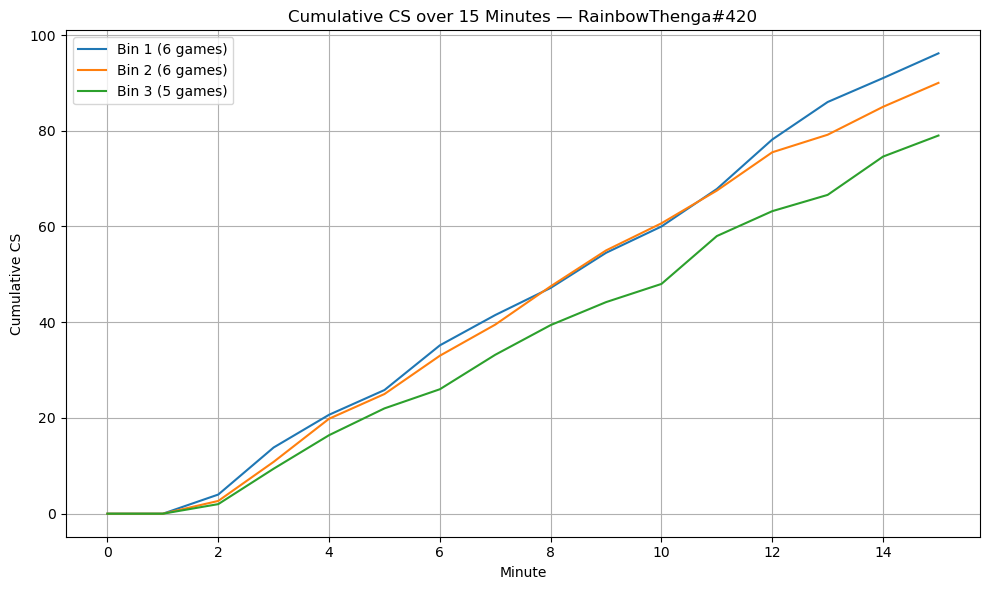

In [12]:
cs_analysis.plot_cumulative_cs_timelines_by_bins(
    user_data_path=repo_root / "data/users/RainbowThenga_420",
    summoner_name="RainbowThenga#420",
    num_matches=20,
    bin_size=6,
    filter_champion="Aphelios"  # optional
)


In [13]:
cs_analysis.cs_at_15_and_early_death_for_recent_matches(
    user_data_path=repo_root / "data/users/RainbowThenga_420",
    summoner_name="RainbowThenga#420",
    num_matches=20,
    filter_champion="Aphelios"
)



🎯 CS@15 + Early Deaths for last 17 matches:
🟥 EUW1_7722495893 |   Aphelios | CS@15:  95 | CS/m: 6.33
🟥 EUW1_7629564332 |   Aphelios | CS@15:  82 | CS/m: 5.47
🟥 EUW1_7629502710 |   Aphelios | CS@15:  69 | CS/m: 4.60
🟩 EUW1_7626564043 |   Aphelios | CS@15: 107 | CS/m: 7.13
🟥 EUW1_7626507283 |   Aphelios | CS@15:  82 | CS/m: 5.47
🟥 EUW1_7625740430 |   Aphelios | CS@15: 111 | CS/m: 7.40
🟥 EUW1_7625719538 |   Aphelios | CS@15:  80 | CS/m: 5.33
🟥 EUW1_7625649918 |   Aphelios | CS@15:  85 | CS/m: 5.67
🟥 EUW1_7625575459 |   Aphelios | CS@15:  71 | CS/m: 4.73
🟥 EUW1_7625461533 |   Aphelios | CS@15:  80 | CS/m: 5.33
🟥 EUW1_7493094990 |   Aphelios | CS@15:  96 | CS/m: 6.40
🟥 EUW1_7492943116 |   Aphelios | CS@15:  98 | CS/m: 6.53
🟥 EUW1_7492855131 |   Aphelios | CS@15:  68 | CS/m: 4.53
🟥 EUW1_7492783057 |   Aphelios | CS@15:  73 | CS/m: 4.87
🟩 EUW1_7492032844 |   Aphelios | CS@15:  83 | CS/m: 5.53
🟥 EUW1_7492003942 |   Aphelios | CS@15:  76 | CS/m: 5.07
🟩 EUW1_7491969365 |   Aphelios | CS@15:  73

[{'match_id': 'EUW1_7722495893',
  'champion': 'Aphelios',
  'cs_at_15': 95,
  'cs_per_min': 6.33,
  'early_death': True},
 {'match_id': 'EUW1_7629564332',
  'champion': 'Aphelios',
  'cs_at_15': 82,
  'cs_per_min': 5.47,
  'early_death': True},
 {'match_id': 'EUW1_7629502710',
  'champion': 'Aphelios',
  'cs_at_15': 69,
  'cs_per_min': 4.6,
  'early_death': True},
 {'match_id': 'EUW1_7626564043',
  'champion': 'Aphelios',
  'cs_at_15': 107,
  'cs_per_min': 7.13,
  'early_death': False},
 {'match_id': 'EUW1_7626507283',
  'champion': 'Aphelios',
  'cs_at_15': 82,
  'cs_per_min': 5.47,
  'early_death': True},
 {'match_id': 'EUW1_7625740430',
  'champion': 'Aphelios',
  'cs_at_15': 111,
  'cs_per_min': 7.4,
  'early_death': True},
 {'match_id': 'EUW1_7625719538',
  'champion': 'Aphelios',
  'cs_at_15': 80,
  'cs_per_min': 5.33,
  'early_death': True},
 {'match_id': 'EUW1_7625649918',
  'champion': 'Aphelios',
  'cs_at_15': 85,
  'cs_per_min': 5.67,
  'early_death': True},
 {'match_id': '